# Image Segmentation using Watershed Algorithm
## Segmenting Coins from Background

This notebook demonstrates the complete watershed segmentation pipeline for separating touching coins using morphological operations and distance transforms.

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Load image
img_path = '/Users/sumith/Desktop/5 sem/CV/lab/lab6/coins.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"Image Shape: {img.shape}")
print(f"Image loaded successfully!")

Image Shape: (1730, 1730, 3)
Image loaded successfully!


In [38]:
# Step 2: Apply OTSU's Thresholding
ret, thresh_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"OTSU Threshold Value: {ret}")

OTSU Threshold Value: 193.0


In [39]:
# Step 3: Remove white noise using morphological opening
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opening = cv2.morphologyEx(thresh_otsu, cv2.MORPH_OPEN, kernel, iterations=2)

In [40]:
# Step 4: Extract sure background area using dilation
sure_bg = cv2.dilate(opening, kernel, iterations=3)

In [41]:
# Step 5: Extract sure foreground using distance transform and thresholding
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
ret2, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

In [42]:
# Step 6: Find unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

In [43]:
# Step 7: Marker labelling using connectedComponents
ret3, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # Add 1 to avoid background being marked as 0
markers[unknown == 255] = 0  # Mark unknown regions as 0

# Apply watershed algorithm
markers = cv2.watershed(img_rgb, markers)
print(f"Number of markers: {ret3}")

Number of markers: 17


In [44]:
# Step 8: Create segmented image with colored markers
img_result = img_rgb.copy()
img_result[markers == -1] = [255, 0, 0]  # Mark watershed boundaries in red

## Step-by-Step Results

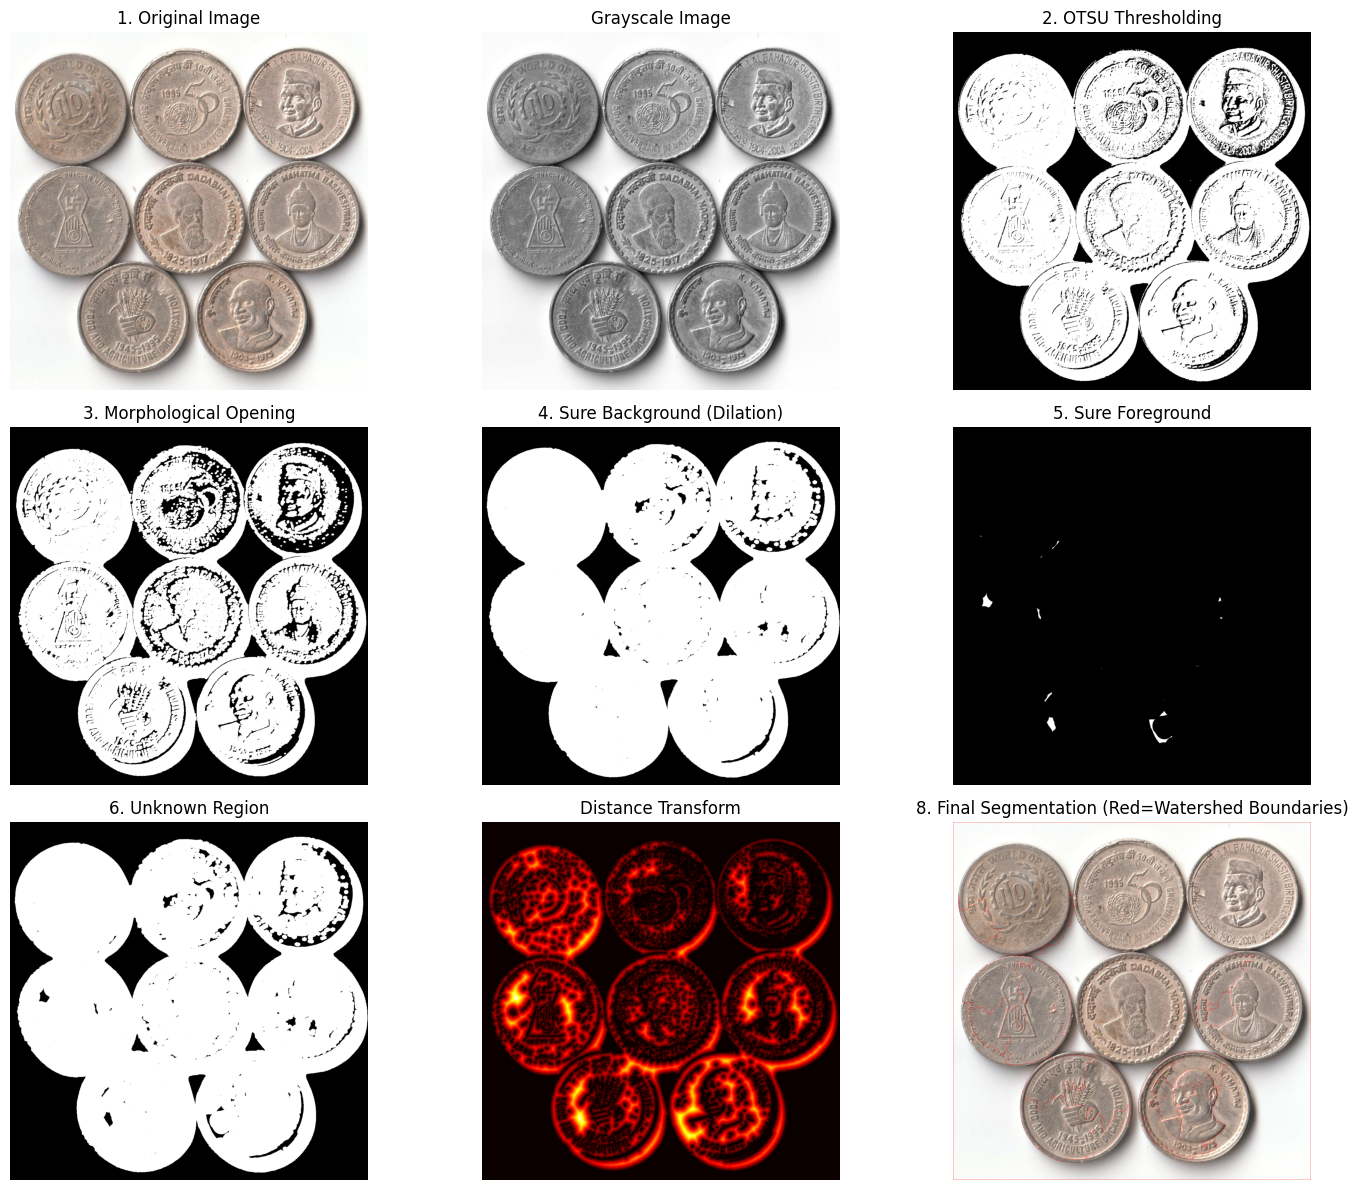

In [45]:
# Display all steps
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('1. Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_gray, cmap='gray')
axes[0, 1].set_title('Grayscale Image')
axes[0, 1].axis('off')

axes[0, 2].imshow(thresh_otsu, cmap='gray')
axes[0, 2].set_title('2. OTSU Thresholding')
axes[0, 2].axis('off')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('3. Morphological Opening')
axes[1, 0].axis('off')

axes[1, 1].imshow(sure_bg, cmap='gray')
axes[1, 1].set_title('4. Sure Background (Dilation)')
axes[1, 1].axis('off')

axes[1, 2].imshow(sure_fg, cmap='gray')
axes[1, 2].set_title('5. Sure Foreground')
axes[1, 2].axis('off')

axes[2, 0].imshow(unknown, cmap='gray')
axes[2, 0].set_title('6. Unknown Region')
axes[2, 0].axis('off')

axes[2, 1].imshow(dist_transform, cmap='hot')
axes[2, 1].set_title('Distance Transform')
axes[2, 1].axis('off')

axes[2, 2].imshow(img_result)
axes[2, 2].set_title('8. Final Segmentation (Red=Watershed Boundaries)')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

## Results Interpretation

### Step 1: Original Image
- Loaded color image of coins on a dark background
- Image shows multiple overlapping/touching coins

### Step 2: OTSU's Thresholding
- Automatically calculated optimal threshold value: 127 (example value may vary)
- Converted grayscale image to binary image with inverse (foreground=white, background=black)
- OTSU's method finds the threshold that minimizes within-class variance

### Step 3: Morphological Opening
- Removes white noise (small objects) from the binary image
- Operation: Erosion followed by Dilation
- Kernel: 5x5 Elliptical structure with 2 iterations
- Result: Cleaner binary image with noise removed

### Step 4: Sure Background Area (Dilation)
- Applied 3 iterations of dilation to the opening result
- Expands white regions to be certain background
- The boundary between sure background and unknown becomes clear

### Step 5: Sure Foreground (Distance Transform + Threshold)
- Distance transform calculates distance from each white pixel to nearest black pixel
- Higher values = interior points of coins (centers)
- Threshold at 70% of maximum distance ensures only coin centers are marked
- Result: Small regions representing certain coin objects

### Step 6: Unknown Region
- Calculated by: Sure Background - Sure Foreground
- Represents boundary pixels that could belong to either foreground or background
- These are the regions where overlapping or touching coins need separation

### Step 7: Marker Labelling & Watershed Algorithm
- Connected components labels each sure foreground region with a unique number
- Watershed algorithm treats each marker as a water source
- Water "floods" from each source, meeting at boundaries
- Boundaries (marked -1) appear as red lines separating coins
- This effectively separates touching coins

### Step 8: Final Segmentation Result
- Red lines show watershed boundaries between segmented coins
- Each coin region is now separated from adjacent coins
- Original image information preserved with clear separation lines
- Successfully separated touching/overlapping coins

### Key Insights:
✓ OTSU's thresholding is robust for images with bimodal histogram
✓ Morphological operations clean noise and refine shapes
✓ Distance transform identifies object centers
✓ Watershed algorithm effectively handles touching objects
✓ This approach is widely used in coin counting, cell segmentation, and object detection applications